
# Lab1_4: PDE_capacitor

In [ ]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

### Potential and Electric field from a capacitor

####Lab1_4_PDE_capacitor:

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}
\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

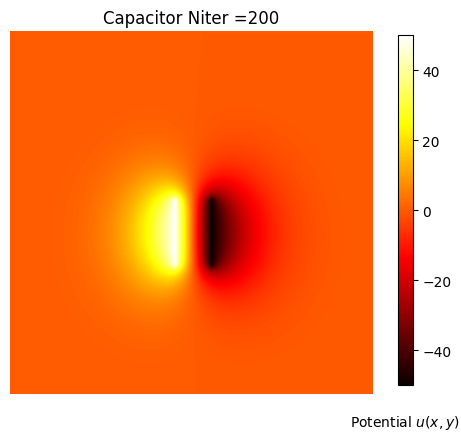

In [ ]:
# let's construc you own rutine. As an example:
from capacitor import capacitor_df #my rutine

# Plot imshow
Niter = 200
V = capacitor_df(Niter)
fig, ax = plt.subplots(figsize=(5,5) )
im = ax.imshow(V.copy(),cmap="hot",interpolation="bilinear",)
ax.set_axis_off()
ax.set_title('Capacitor Niter =%.1d'%Niter)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("Potential $u(x,y)$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

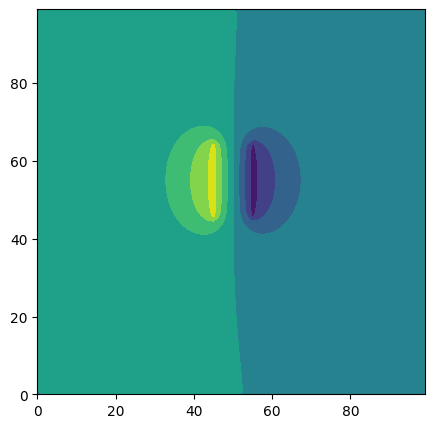

In [ ]:
plt.subplots(figsize=(5,5) )
plt.contourf(V)
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def capacitor_df(Niter=200, N=100, tol=1e-5):
    """
    Resuelve la ecuación de Laplace para un capacitor de placas paralelas
    usando diferencias finitas (método de relajación)

    Parámetros:
    -----------
    Niter : int
        Número máximo de iteraciones
    N : int
        Tamaño de la grilla (N x N)
    tol : float
        Tolerancia para la convergencia

    Retorna:
    --------
    V : ndarray
        Potencial en la grilla
    """

    # Inicializar la grilla de potencial
    V = np.zeros((N, N))

    # Definir las placas del capacitor
    plate_width = N // 4  # Ancho de las placas
    plate_gap = N // 5     # Separación entre placas
    plate_center = N // 2

    # Posiciones de las placas
    plate1_y = plate_center - plate_gap // 2
    plate2_y = plate_center + plate_gap // 2
    plate_start_x = (N - plate_width) // 2
    plate_end_x = plate_start_x + plate_width

    # Condiciones de frontera: Placas con potencial fijo
    V[plate1_y, plate_start_x:plate_end_x] = 1.0   # Placa superior a +1V
    V[plate2_y, plate_start_x:plate_end_x] = -1.0  # Placa inferior a -1V

    # Crear máscara para las placas (no se actualizan durante la relajación)
    mask = np.zeros_like(V, dtype=bool)
    mask[plate1_y, plate_start_x:plate_end_x] = True
    mask[plate2_y, plate_start_x:plate_end_x] = True

    # Método de relajación para resolver la ecuación de Laplace
    for iteration in range(Niter):
        V_old = V.copy()

        # Actualizar puntos interiores (excepto las placas)
        for i in range(1, N-1):
            for j in range(1, N-1):
                if not mask[i, j]:
                    V[i, j] = 0.25 * (V[i+1, j] + V[i-1, j] +
                                     V[i, j+1] + V[i, j-1])

        # Condiciones de frontera de Neumann en los bordes
        V[0, :] = V[1, :]
        V[-1, :] = V[-2, :]
        V[:, 0] = V[:, 1]
        V[:, -1] = V[:, -2]

        # Reaplicar condiciones fijas en las placas
        V[plate1_y, plate_start_x:plate_end_x] = 1.0
        V[plate2_y, plate_start_x:plate_end_x] = -1.0

        # Verificar convergencia
        diff = np.max(np.abs(V - V_old))
        if diff < tol:
            print(f"Convergencia alcanzada en {iteration+1} iteraciones")
            break

    return V

def compute_electric_field(V, dx=1.0):
    """
    Calcula el campo eléctrico a partir del potencial usando diferencias finitas

    Parámetros:
    -----------
    V : ndarray
        Potencial en la grilla
    dx : float
        Espaciado de la grilla

    Retorna:
    --------
    Ex, Ey : ndarray
        Componentes del campo eléctrico
    E_magnitude : ndarray
        Magnitud del campo eléctrico
    """

    Ny, Nx = V.shape

    # Inicializar arrays para el campo eléctrico
    Ex = np.zeros_like(V)
    Ey = np.zeros_like(V)

    # Calcular derivadas usando diferencias centrales
    # E = -∇V
    for i in range(1, Ny-1):
        for j in range(1, Nx-1):
            Ex[i, j] = -(V[i, j+1] - V[i, j-1]) / (2 * dx)
            Ey[i, j] = -(V[i+1, j] - V[i-1, j]) / (2 * dx)

    # Magnitud del campo eléctrico
    E_magnitude = np.sqrt(Ex**2 + Ey**2)

    return Ex, Ey, E_magnitude


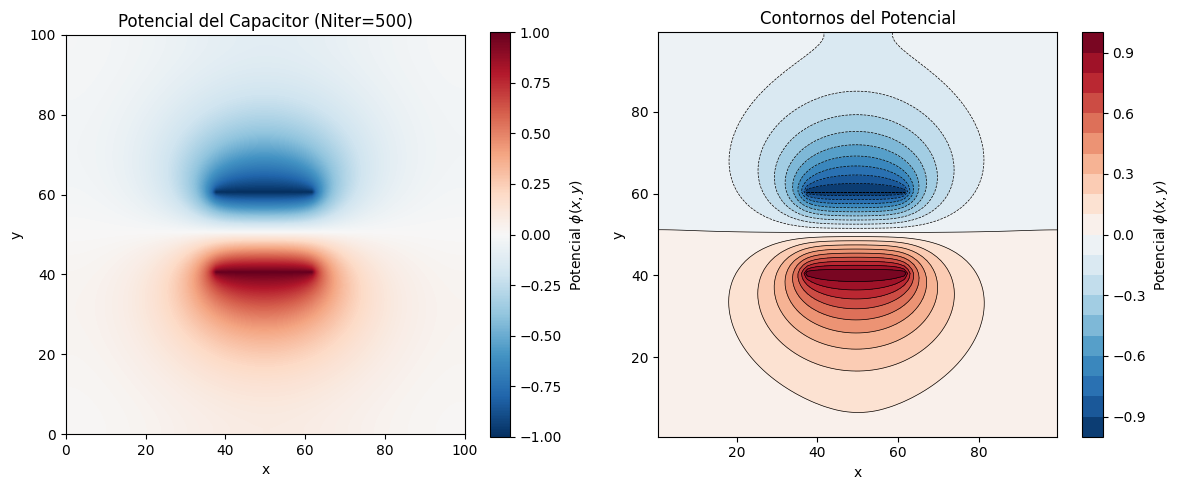

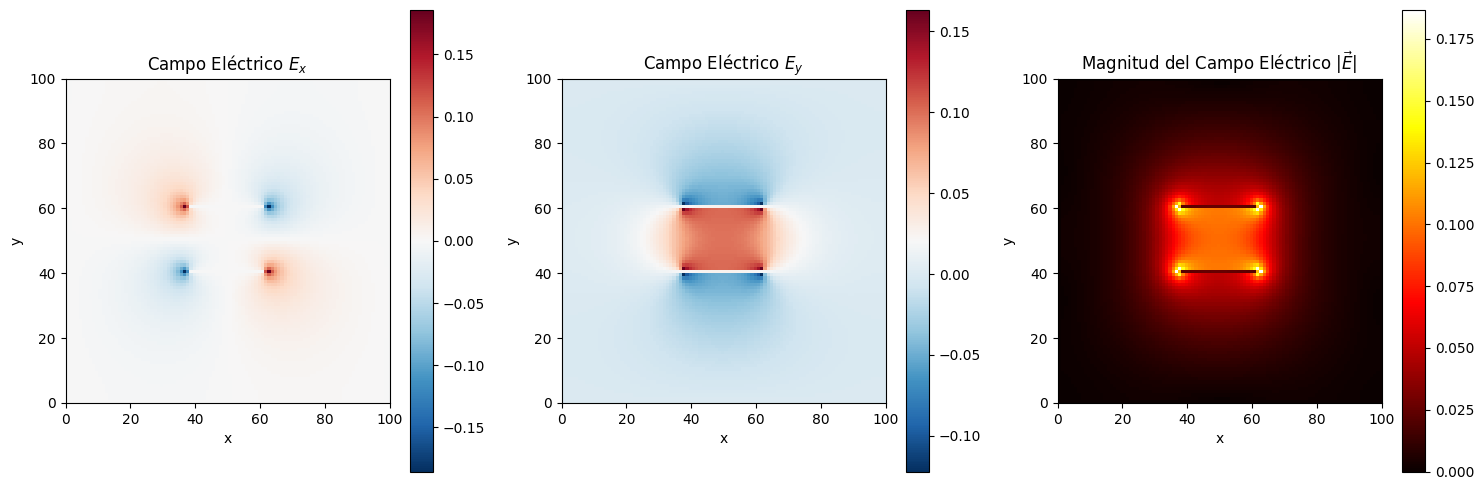

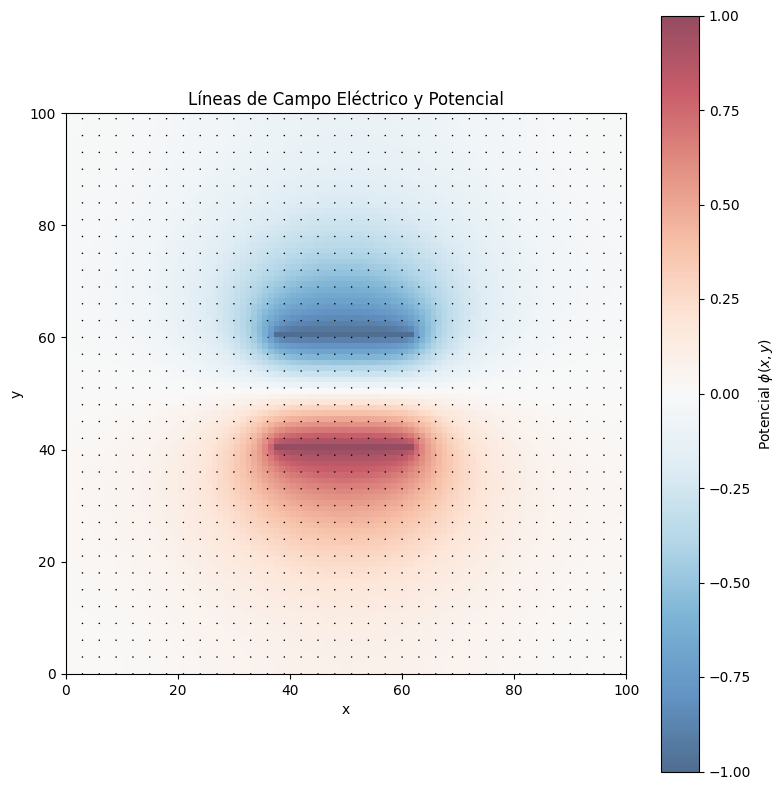


=== Análisis del Campo Eléctrico ===
Magnitud promedio del campo entre placas: 0.0914
Componente Ex promedio: 0.0000
Componente Ey promedio: 0.0914

Nota: Para placas infinitas, teóricamente:
|E| ≈ σ/(2ε₀) en el interior, E ≈ 0 en el exterior


In [3]:
# Resolver para el capacitor
Niter = 500
V = capacitor_df(Niter, N=100)

# Calcular el campo eléctrico
Ex, Ey, E_magnitude = compute_electric_field(V)

# Visualización del potencial
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot con imshow
im = axes[0].imshow(V, cmap="RdBu_r", interpolation="bilinear",
                    extent=[0, 100, 0, 100], origin='lower')
axes[0].set_title(f'Potencial del Capacitor (Niter={Niter})')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Añadir colorbar
cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label('Potencial $\\phi(x,y)$')

# Plot con contourf
contour = axes[1].contourf(V, levels=20, cmap="RdBu_r",
                           extent=[0, 100, 0, 100], origin='lower')
axes[1].contour(V, levels=20, colors='black', linewidths=0.5,
                extent=[0, 100, 0, 100], origin='lower')
axes[1].set_title('Contornos del Potencial')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

cbar2 = fig.colorbar(contour, ax=axes[1])
cbar2.set_label('Potencial $\\phi(x,y)$')

plt.tight_layout()
plt.show()

# Visualización del campo eléctrico
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Componente Ex
im1 = axes[0].imshow(Ex, cmap="RdBu_r", extent=[0, 100, 0, 100], origin='lower')
axes[0].set_title('Campo Eléctrico $E_x$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im1, ax=axes[0])

# Componente Ey
im2 = axes[1].imshow(Ey, cmap="RdBu_r", extent=[0, 100, 0, 100], origin='lower')
axes[1].set_title('Campo Eléctrico $E_y$')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(im2, ax=axes[1])

# Magnitud del campo eléctrico
im3 = axes[2].imshow(E_magnitude, cmap="hot", extent=[0, 100, 0, 100], origin='lower')
axes[2].set_title('Magnitud del Campo Eléctrico $|\\vec{E}|$')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

# Visualización de líneas de campo eléctrico
fig, ax = plt.subplots(figsize=(8, 8))

# Crear grilla para las flechas (submuestreo para mejor visualización)
stride = 3
y, x = np.mgrid[0:100:stride, 0:100:stride]

# Plot del potencial de fondo
im = ax.imshow(V, cmap="RdBu_r", alpha=0.7, extent=[0, 100, 0, 100], origin='lower')

# Añadir vectores del campo eléctrico
ax.quiver(x, y, Ex[::stride, ::stride], Ey[::stride, ::stride],
          scale=50, width=0.003, color='black')

ax.set_title('Líneas de Campo Eléctrico y Potencial')
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.colorbar(im, ax=ax, label='Potencial $\\phi(x,y)$')
plt.tight_layout()
plt.show()

# Análisis del campo eléctrico en la región entre placas
plate_center_y = 50
plate_start_x = 37
plate_end_x = 62

# Región entre placas
mid_region_y = plate_center_y
mid_region_x = slice(plate_start_x, plate_end_x)



In [4]:
print("\n=== Análisis del Campo Eléctrico ===")
print(f"Magnitud promedio del campo entre placas: {np.mean(E_magnitude[mid_region_y, mid_region_x]):.4f}")
print(f"Componente Ex promedio: {np.mean(Ex[mid_region_y, mid_region_x]):.4f}")
print(f"Componente Ey promedio: {np.mean(Ey[mid_region_y, mid_region_x]):.4f}")

# Teóricamente, para placas infinitas: |E| ≈ σ/(2ε₀) en el interior
print("\nNota: Para placas infinitas, teóricamente:")
print("|E| ≈ σ/(2ε₀) en el interior, E ≈ 0 en el exterior")


=== Análisis del Campo Eléctrico ===
Magnitud promedio del campo entre placas: 0.0914
Componente Ex promedio: 0.0000
Componente Ey promedio: 0.0914

Nota: Para placas infinitas, teóricamente:
|E| ≈ σ/(2ε₀) en el interior, E ≈ 0 en el exterior
